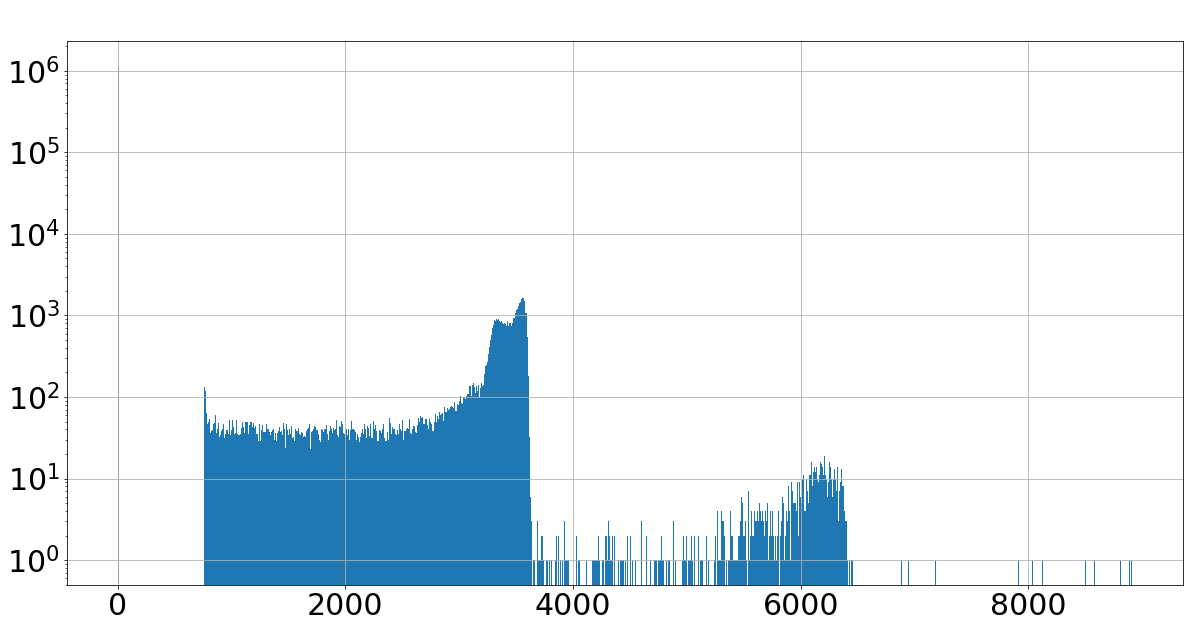

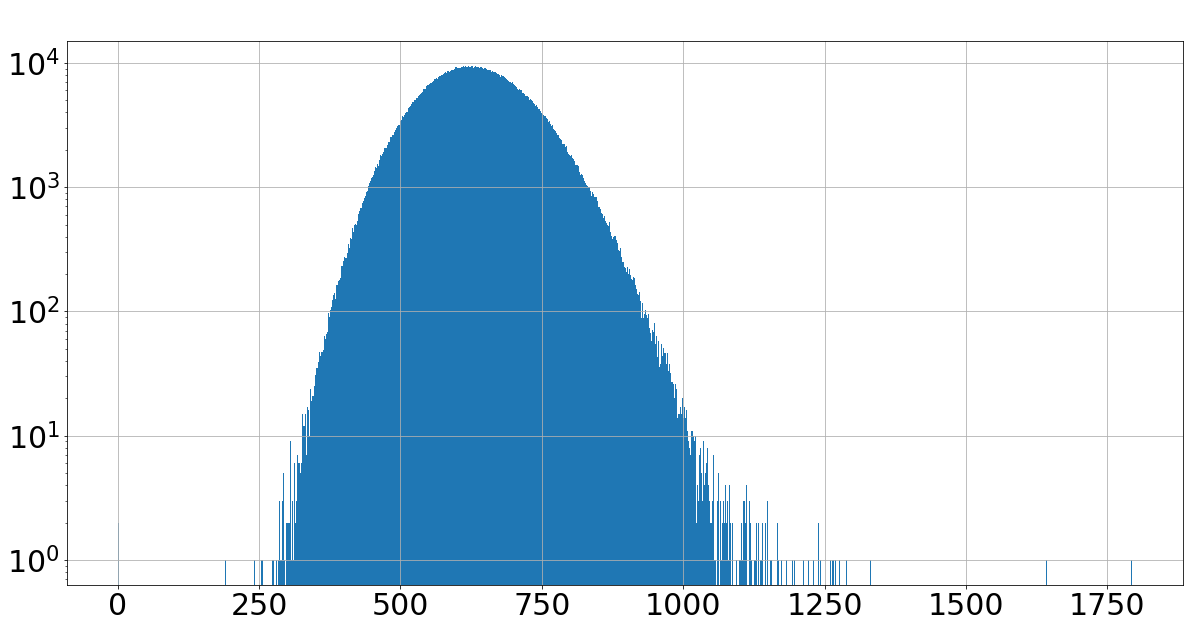

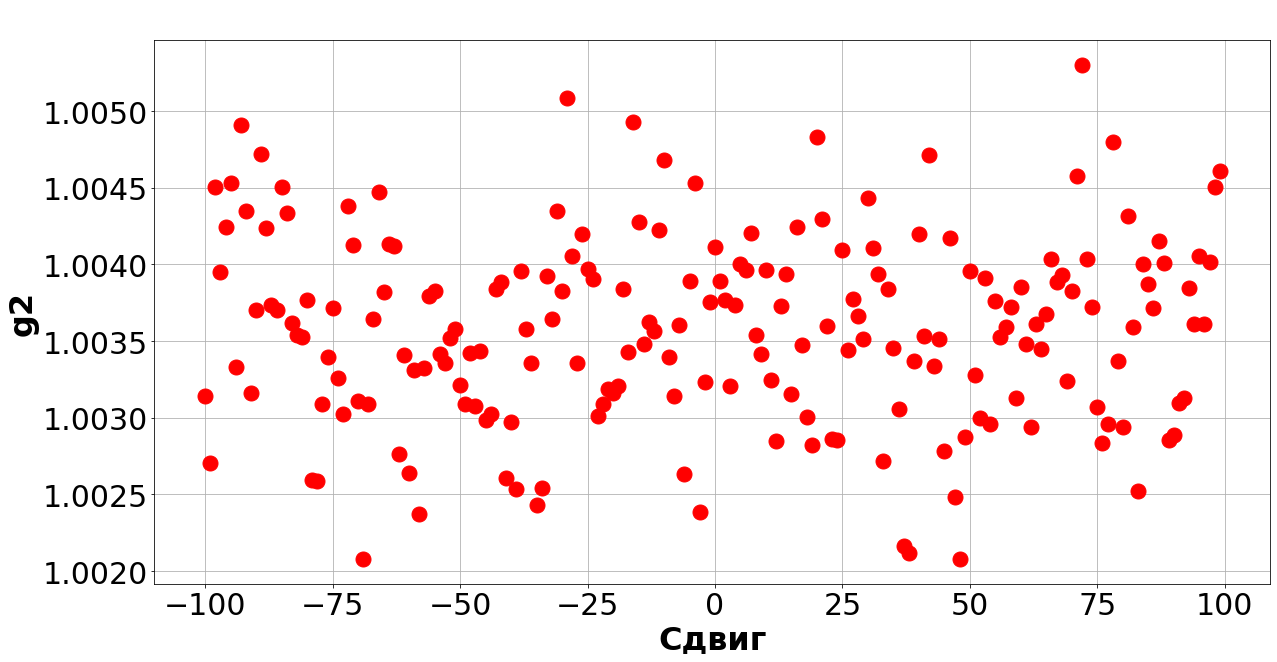

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def log_hist(x):
    f = plt.figure() 
    f.set_figwidth(20) 
    f.set_figheight(10)
    plt.title(' ') #заголовок
    plt.grid() #сетка
    plt.rc('axes', labelsize = 15) #размер чиселок у осей
    plt.yscale('log')
    plt.hist(x, bins = 1000)
 
    
def delete_noize_new(my_file, E, B, C, D, F, K, N, new_file, w=False):
    f = open(my_file)

    A = []
    for line in f:
        a = float(line)
        if ((a > E and B > a) or (a > C and D > a) or (a > F and K > a)):
            A.append(a - N)
        else:
            A.append(0.0)
    B = np.copy(A)
    if w:
        np.savetxt(new_file, B, fmt='%f')
    log_hist(B)
    return B


def SDVGcorr(X, Y, A, B):
    len_x = len(X)
    C = np.linspace(0, 0, len_x)
    x = np.mean(X)
    y = np.mean(Y)
    g = []
    for t in range(A, 0):
        for i in range(len_x):
            C[i] = X[i+t] * Y[i]
        c = np.mean(C)
        g += [(c / (x * y))]
    for t in range(0, B):
        for i in range(len_x):
            C[i] = X[i] * Y[i-t]
        c = np.mean(C)
        g += [(c / (x * y))]
    x = range(A, B)
    f = plt.figure() 
    f.set_figwidth(20) 
    f.set_figheight(10)
    plt.title(' ') #заголовок
    plt.plot(x,g,'ro', markersize = 15) #точки
    plt.xlabel("Сдвиг", fontsize = 32, fontweight="bold") #подписи к осям
    plt.ylabel("g2", fontsize = 32, fontweight="bold")
    plt.grid() #сетка
    plt.rc('axes', labelsize = 25) #размер чиселок у осей  
    return g
def G(X, Y, A, B):
    len_x = len(X)
    C = np.linspace(0, 0, len_x)
    x = np.mean(X)
    y = np.mean(Y)
    for i in range(len_x):
        C[i] = X[i] * Y[i]
    c = np.mean(C)
    g = c / (x * y)
    gschet = (g-1)*100/8+1
    dx = (np.std(X)) / np.sqrt(len_x - 1)
    dy = (np.std(Y)) / np.sqrt(len_x - 1)
    dc = (np.std(C)) / np.sqrt(len_x - 1)
    dg = g * np.sqrt(((dx / x) ** 2) + ((dy / y) ** 2) + (dc / c) ** 2)
    XX = X*y/x
    alpha = y/x
    # dg = np.sqrt( (dc/x*y)**2 + (c*dy/(x*y**2))**2 + (c*dx/(y*x**2))**2 )
    Q = 52
    NRF = (np.var(XX-Y)/np.mean(XX+Y))/Q

    eff_1 = 100 * (g - 1) * (x / A)
    deff1 = 100 * np.sqrt((x * dg / A) ** 2 + ((g - 1) * dx / A) ** 2)
    eff_2 = 100 * (g - 1) * (y / B)
    deff2 = 100 * np.sqrt((y * dg / B) ** 2 + ((g - 1) * dy / B) ** 2)
    dNRF = np.sqrt(((dx / x) ** 2) + ((dy / y) ** 2)) * NRF
    
    with open(file_name, "a+") as fileVar:
        output = str(k) + " " + str(k1) + " " + str(round(g, 5)) + " " + str(round(dg, 5)) + " " + str(round(x, 5)) + " " + \
                 str(round(y, 5)) + " " + str(round(eff_1, 5)) + " " + str(round(deff1, 5)) + " " + \
                 str(round(eff_2, 5)) + " " + str(round(deff2, 5)) + " " + str(round(NRF, 5)) + " " + \
                 str(round(dNRF, 5)) + " " + str(round(alpha, 5)) + " " + \
                 str(round(gschet, 5)) + "\n"
        fileVar.write(output)

    return g
i = 0
filesF = ['C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m30(0)s500d100shumF.txt',   
               'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m50(13.1)s500d100F.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m36(3.5)s500d100F.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt']
filesO =  ['C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m30(0)s500d100shumO.txt',   
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m50(13.1)s500d100O.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/m36(3.5)s500d100O.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt',
                'C:/Users/Екатерина/Desktop/Экспериенты со счетным ФЭУ/FN в сигнальном канале/ФЭУ+ЛФД строб 500нс min (gain 600)/.txt']
    
for i in range (2,3):
    filename1 = filesF[i]
    filename  = filesO[i]    
    # лфд - O
    X = delete_noize_new(filename, 762, 999999, 0, 0, 0, 0, 0.08832618918734232, 'new_file1.txt') #0.08832618918734232
    # фэу - F
    Y = delete_noize_new(filename1, 0, 9999999, 0, 0, 0, 0, 354.58698447447375, 'new_file2.txt') #354.58698447447375
    g2 = SDVGcorr(X, Y, -100, 100) 
    #g = G(X, Y, 1361, 70) 

plt.show()
#3312.2348547187503